In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load our finished master dataset
master = pd.read_excel("../data/cleaned/master_dataset.xlsx")

print(master.shape)
master.head()

(52930, 20)


,TransactionId,UserId,VisitYear,VisitMonth,AttractionId,Rating,VisitMode,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,ContinentId,RegionId,CountryId,CityId,Continent,Region,Country,CityName
0,3,70456,2022,10,640,5,Couples,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,5,21,163,4341,Europe,Western Europe,United Kingdom,Guildford
1,8,7567,2022,10,640,5,Friends,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,2,8,48,464,America,Northern America,Canada,Ontario
2,9,79069,2022,10,640,5,Family,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,2,9,54,774,America,South America,Brazil,Brazil
3,10,31019,2022,10,640,3,Family,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,5,17,135,583,Europe,Central Europe,Switzerland,Zurich
4,15,43611,2022,10,640,3,Couples,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,5,21,163,1396,Europe,Western Europe,United Kingdom,Manchester


C:\Users\avani\AppData\Local\Temp\ipykernel_16528\59983292.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master, x='Rating', palette='viridis')


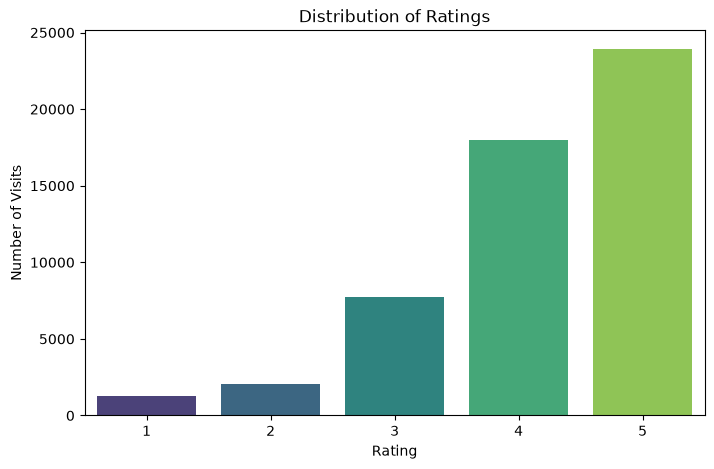

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(data=master, x='Rating', palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Visits')
plt.show()

# Which attraction types are most popular?

C:\Users\avani\AppData\Local\Temp\ipykernel_16528\2145680629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attraction_counts.values, y=attraction_counts.index, palette='mako')


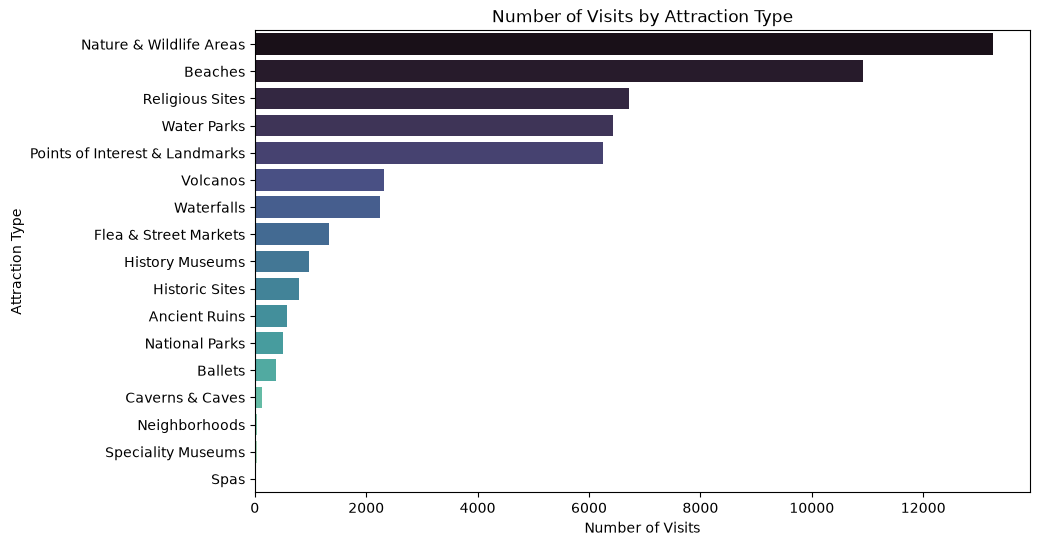

In [3]:
plt.figure(figsize=(10, 6))
attraction_counts = master['AttractionType'].value_counts()
sns.barplot(x=attraction_counts.values, y=attraction_counts.index, palette='mako')
plt.title('Number of Visits by Attraction Type')
plt.xlabel('Number of Visits')
plt.ylabel('Attraction Type')
plt.show()

# Do ratings vary by attraction type?

C:\Users\avani\AppData\Local\Temp\ipykernel_16528\16565286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_type.values, y=avg_rating_by_type.index, palette='crest')


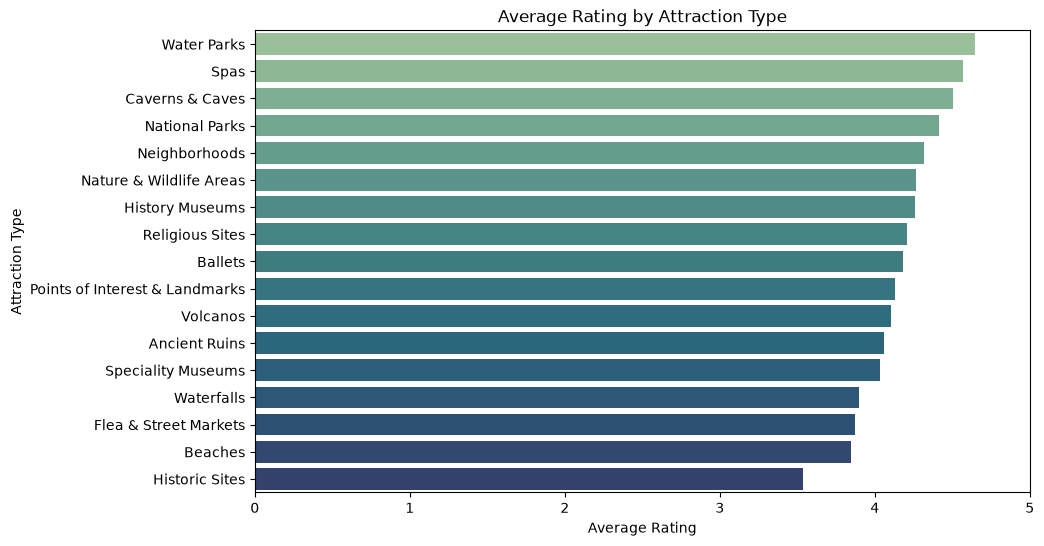

In [4]:
plt.figure(figsize=(10, 6))
avg_rating_by_type = master.groupby('AttractionType')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating_by_type.values, y=avg_rating_by_type.index, palette='crest')
plt.title('Average Rating by Attraction Type')
plt.xlabel('Average Rating')
plt.xlim(0, 5)
plt.ylabel('Attraction Type')
plt.show()

# How does VisitMode relate to Rating?

C:\Users\avani\AppData\Local\Temp\ipykernel_16528\4031479173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master, x='VisitMode', y='Rating', palette='Set2')


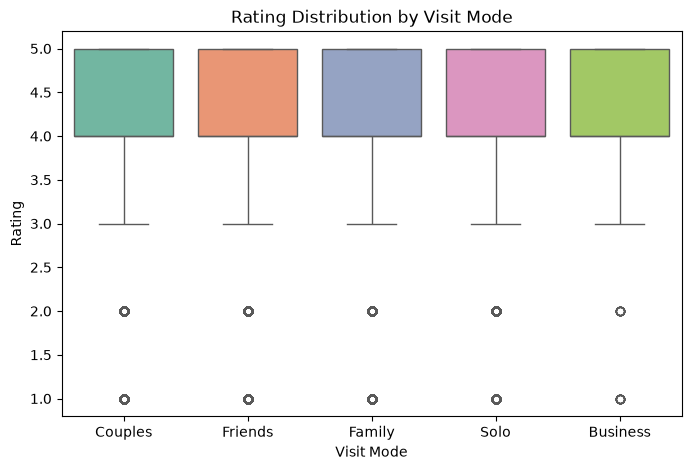

In [5]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=master, x='VisitMode', y='Rating', palette='Set2')
plt.title('Rating Distribution by Visit Mode')
plt.xlabel('Visit Mode')
plt.ylabel('Rating')
plt.show()

# 
1. The line in the middle of the box = median rating
2. The box itself = where the middle 50% of ratings fall
3. The dots above/below = outliers (unusual ratings)
4. visit mode doesn't strongly affect satisfaction; people rate similarly whether traveling with family, friends, as a couple, etc.

# Geography — which continents/regions visit the most?

C:\Users\avani\AppData\Local\Temp\ipykernel_16528\159360479.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=continent_counts.values, y=continent_counts.index, palette='flare')


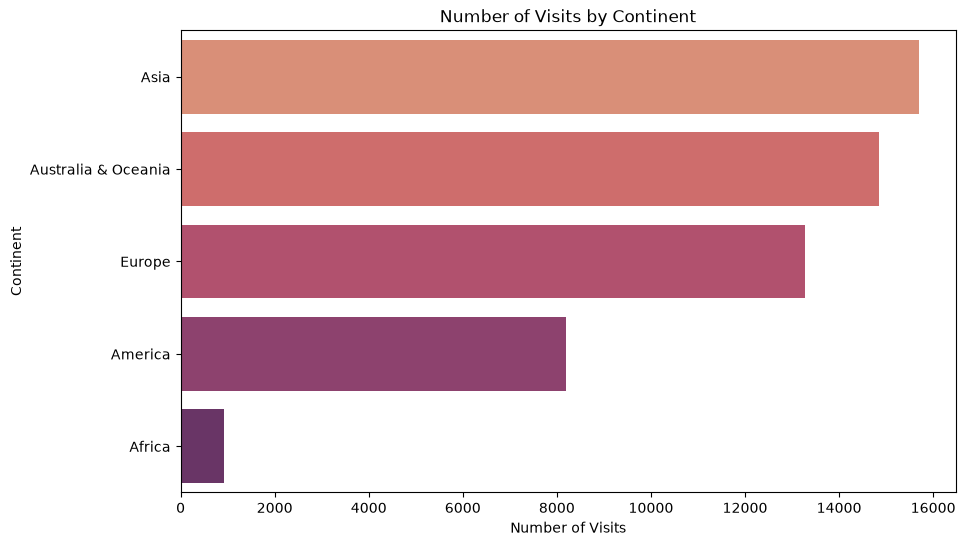

In [6]:
plt.figure(figsize=(10, 6))
continent_counts = master['Continent'].value_counts()
sns.barplot(x=continent_counts.values, y=continent_counts.index, palette='flare')
plt.title('Number of Visits by Continent')
plt.xlabel('Number of Visits')
plt.ylabel('Continent')
plt.show()

# Visit trends over time — is tourism growing?

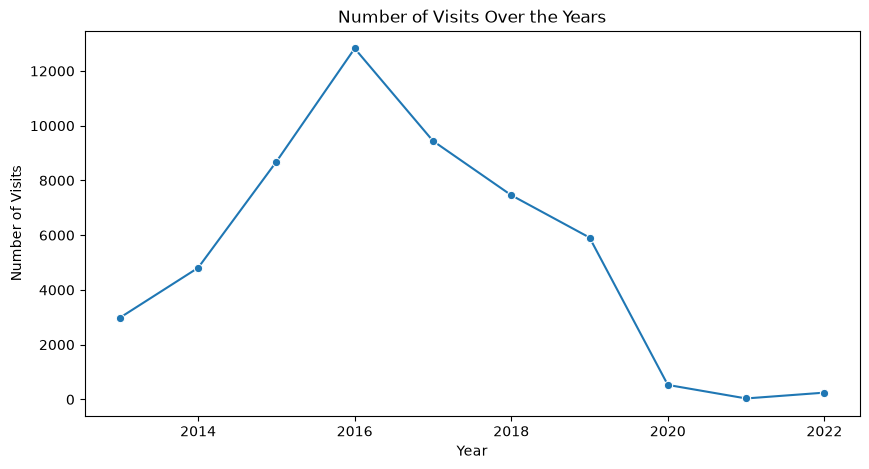

In [7]:
plt.figure(figsize=(10, 5))
yearly_counts = master['VisitYear'].value_counts().sort_index()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o')
plt.title('Number of Visits Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Visits')
plt.show()

# Correlation between numeric features

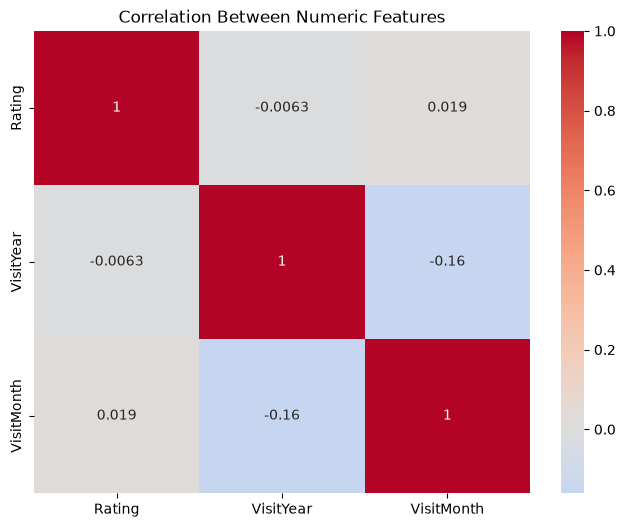

In [8]:
plt.figure(figsize=(8, 6))
numeric_cols = master[['Rating', 'VisitYear', 'VisitMonth']]
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Features')
plt.show()

# 
a correlation heatmap tells us how strongly two numeric variables move together, on a scale from -1 to +1:

1. Close to +1 → strongly move together (e.g. as one goes up, so does the other)
2. Close to -1 → strongly move opposite (as one goes up, other goes down)
3. Close to 0 → basically unrelated